#  التحويلات الهندسية للصور:
###  الهدف:

تعلم اجراء تحويلات هندسية مختلفة , مثل النقل , التدوير , وتحويل ال(التوازي)ال
`affine`

وسنرى هذه التوابع:

- `cv2.getPerspectiveTransform`

###  التحويلات:
يقدم 
**OpenCV**
تابعين للتحويل:

- `cv2.wrapAffine` , `cv2.wrapPerspective`

واللذين يمكن انجاز كل انواع التحويلات بهما , الاول ياخذ مصفوفة تحويل
بحجم
`2X3`
اما الثاني فقياس مصفوفته 
`3X3`

### التحجيم:

التحجيم هو فقط , تحديد قياس الصورة والمكتبة تقدم تابعا لهذا
`cv2.resize`
قياس الصورة يمكن تحديده يدوياً او يمكن تحديد عامل التحجيم , وهناك عدة طرق ممكنة للاستيفاء  , كالتالي:

- `cv2.INTER_AREA`
- `cv2.INTER_CUBIC ` 
- `cv2.INTER_LINEAR`

الاول للتقليص , والثاني للتكبير , وافتراضياً تستخدم الطريقة الاخيرة لكل حالات التحجيم , والتالي يبين تطبيق الطرق المختلفة الممكنة لذلك

In [1]:
import cv2
import numpy as np

img = cv2.imread('Rene_Decart.jpg')

res = cv2.resize(img,None,fx=2, fy=2, interpolation = cv2.INTER_CUBIC)

# OR

height, width = img.shape[:2]
res = cv2.resize(img,(2*width, 2*height), interpolation = cv2.INTER_CUBIC)

##  النقل:
النقل هو ازاحة مكان جسم ما , واذا عرفت مقدار الازاحة بالاحداثيات فرضاً
`tx , ty`
يمكنك انشاء مصفوفة التحويل كالتالي:
انظر للمثال ادناه , لازاحة بمقدار , `(100,5)`كالتالي


<div dir=ltr>
$$ M = \begin{bmatrix}1 && 0 && t_x\\ 0 && 1 && t_y \end{bmatrix} $$
   
</div>



   ومن ثم يمكنك تحويل M لصيغة 
`np.float32`
وتمريرها للتابع
`cv2.wrapAffine`

In [2]:
%matplotlib inline

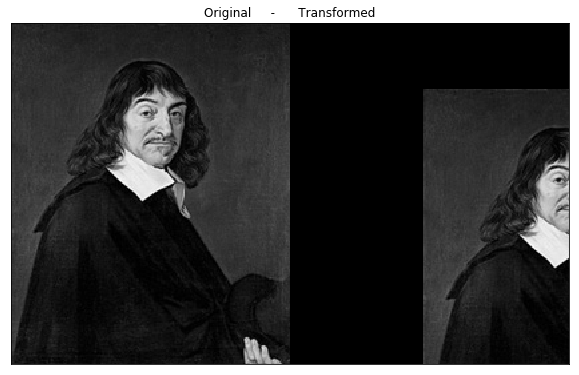

In [4]:
from matplotlib import pyplot as plt

img = cv2.imread('Rene_Decart.jpg',0)
rows,cols = img.shape

M = np.float32([[1,0,100],[0,1,50]])
dst = cv2.warpAffine(img,M,(cols,rows))

res = np.hstack([img , dst])
plt.figure(figsize=[10,10])
plt.imshow(res,cmap = 'gray')
plt.xticks([])
plt.yticks([])
plt.title('Original     -      Transformed')
plt.show()

###  تحذير:
المتغير الثالث لتابع التحويل , هو قياس صورة الخرج , وهو يعطى بالشكل , 
**(width,height)**

## التدوير: 
تدوير الصورة بزاوية , يتم من خلال مصفوفة التحويل من الشكل 


<div dir="ltr">
$$ M = \begin{bmatrix}\cos(\theta) && -\sin(\theta)\\ \sin(\theta) && \cos(\theta) \end{bmatrix} $$
</div>

        
ولكن يمكن ل 
**OpenCV**
اعطاء مصفوفة للتدوير حول اي نقطة وبأي زاوية  ,
ولكن اولاً يجب ايجاد المصفوفة الموافقة من خلال تابع اخر
`cv2.getRotationMatrix2D`

المثال التالي يدور الصورة بزاوية 90 درجة , بدون اي تحجيم 

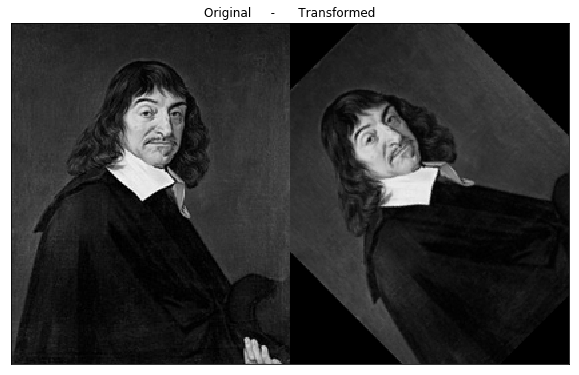

In [7]:
M = cv2.getRotationMatrix2D((cols/2,rows/2),45,1)
dst = cv2.warpAffine(img,M,(cols,rows))

res = np.hstack([img , dst])
plt.figure(figsize=[10,10])
plt.imshow(res,cmap = 'gray')
plt.xticks([])
plt.yticks([])
plt.title('Original     -      Transformed')
plt.show()

##  تحويلAffine :

بالتحويل هذا , كل الخطوط المتوازية بالصورة الاصلية , ستبقى متوازية بصورة الخرج , ولايجاد مصفوفة التحويل ,نحتاج ثلاث نقاط من الصورة الاصلية ونظيرتها بصورة الخرج ,وبعدها 
التابع
`cv2.getAffineTransform `
سينشأ مصفوفة التحويل
`2X3`
والتي سيتم تمريرها ل 
`cv2.wrapAffine`

تفحص المثال ادناه , وانظر للنقاط المختارة 

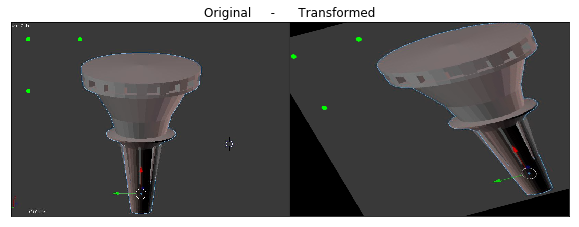

In [8]:
img = cv2.imread('wt.jpg')
rows,cols,ch = img.shape

pts1 = np.float32([[50,50],[200,50],[50,200]])
pts2 = np.float32([[10,100],[200,50],[100,250]])

for x in pts1:
    cv2.circle(img ,(int(x[0]),int(x[1])), 6 , [0 ,255 ,0],-1 )

M = cv2.getAffineTransform(pts1,pts2)

dst = cv2.warpAffine(img,M,(cols,rows))

for x in pts2:
    cv2.circle(dst ,(int(x[0]),int(x[1])), 6 , [0 ,255 ,0],-1 )

res = np.hstack([img , dst])
plt.figure(figsize=[10,10])
plt.imshow(res,cmap = 'gray')
plt.xticks([])
plt.yticks([])
plt.title('Original     -      Transformed')
plt.show()

### التحويل المنظوري :
لهذا التحويل تحتاج مصفوفة 
`3X3`
والخطوط المستقيمة ستبقى كذلك بعد التحويل , لايجاد التحويل تحتاج اربع نقاط بصورة الدخل والنقاط المقابلة بصورة الخرج , و اي ثلاثة منهم يجب الا يكونوا على استقامة واحدة ,
وعندها يمكن ايجاد مصفوفة التحويل , من خلال التابع
`cv2.getPerspectiveTransform` 
وبعدها طبق :
`cv2.warpPerspective`
مع مصفوفة التحويل 
بحجم
`3X3`
كما الكود التالي:

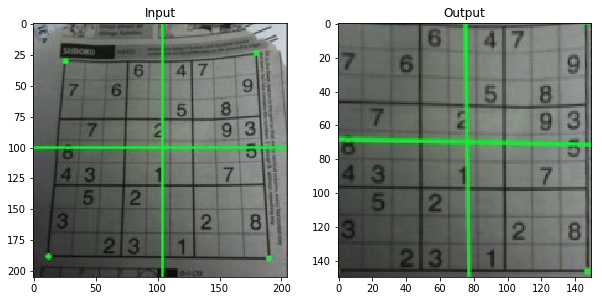

In [9]:
img = cv2.imread('sudokusmall.bmp')
rows,cols,ch = img.shape

pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])/2
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])/2

M = cv2.getPerspectiveTransform(pts1,pts2)

dst = cv2.warpPerspective(img,M,(150,150))

plt.figure(figsize=[10,10])
plt.subplot(121),plt.imshow(img),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')
plt.show()

In [10]:
print M

[[  1.05587376e+00   9.18151097e-02  -3.25484564e+01]
 [  4.69010049e-02   1.12562412e+00  -3.78960120e+01]
 [  3.66502896e-04   1.02667400e-03   1.00000000e+00]]


## : مراجع اضافية
1. “Computer Vision: Algorithms and Applications”, Richard Szeliski